<a href="https://colab.research.google.com/github/lzhanglynn/Substance-Use/blob/main/Copy_MAT599_Object_Localization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

:# Project 4: Object_Localization

Task: Model the Wildfire Smoke dataset
Data types: Images of widlfires takens fron surveillance towers
Target: bounding boxes identifying the location of the smoke in the image
Created by: Ling Zhang
Date: April 28, 2026


**Q1: Load the data and write a function that displays a training image chosen at random with its ground truth bounding box.**

In [ ]:
import os
import random
import zipfile
import pathlib

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from PIL import Image
from matplotlib import pyplot as plt
import matplotlib.patches as patches

# Set seeds
def set_seeds(seed=599):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    Device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print('Using device:', Device)




In [ ]:
# Download data from the upload files
def smoke_data(
    zip_path='/content/wildfire_smoke.zip',
    extract_dir='/content/wildfire data.zip'
):
    # pathlib is imported as a module, so use pathlib.Path
    zip_path_obj = pathlib.Path(zip_path)
    extract_dir_obj = pathlib.Path(extract_dir)

    if zip_path_obj.suffix == ".zip":
        with zipfile.ZipFile(zip_path_obj, 'r') as zip_ref:
            zip_ref.extractall(extract_dir_obj)
        print(f"'{zip_path_obj.name}' extracted successfully to '{extract_dir_obj}'")
    else:
        raise ValueError(f"Unsupported file type: {zip_path_obj}")


In [ ]:
set_seeds(599)

# Define paths and extract the data
ZIP_PATH = '/content/wildfire_smoke.zip'
# Changed name to avoid conflict with zip extension
EXTRACT_ROOT_DIR = '/content/wildfire_data'

smoke_data(zip_path=ZIP_PATH, extract_dir=EXTRACT_ROOT_DIR)

Using device: cpu
'wildfire_smoke.zip' extracted successfully to '/content/wildfire_data'


In [ ]:
import os
from PIL import Image

# Updated to match the new extraction path
EXTRACT_ROOT_DIR = '/content/wildfire_data'
extraction_path = os.path.join(EXTRACT_ROOT_DIR, 'wildfire_smoke')

image_paths = []
all_labels = []

# Check if the path exists before proceeding
if os.path.exists(extraction_path):
    print(f"The path '{extraction_path}' exists.")
else:
    print(f"The path '{extraction_path}' does not exist.")

# Define the splits and parse the bounding box coordinates
splits = ['train', 'valid', 'test']

for split_dir in splits:
    current_split_path = os.path.join(extraction_path, split_dir)
    annotations_file_path = os.path.join(current_split_path, '_annotations.txt')

    if os.path.exists(annotations_file_path):
        with open(annotations_file_path, 'r') as f:
            for line in f:
                parts = line.strip().split(' ', 1)
                if len(parts) == 2:
                    img_filename = parts[0]
                    bbox_str = parts[1]
                    bbox_coords = bbox_str.split(',')
                    if len(bbox_coords) >= 4:
                        xmin, ymin, xmax, ymax = map(int, bbox_coords[:4])
                        full_image_path = os.path.join(current_split_path, img_filename)
                        if os.path.exists(full_image_path):
                            image_paths.append(full_image_path)
                            all_labels.append([xmin, ymin, xmax, ymax])
    else:
        print(f'Annotations file not found for split: {split_dir}')

print(f'Found {len(image_paths)} images with bounding box annotations.')

The path '/content/wildfire_data/wildfire_smoke' exists.
Found 737 images with bounding box annotations.


In [ ]:
# Define the function

def display_random_image_with_bbox(image_paths, all_labels):
    """
    Displays a random image from the dataset with its ground truth bounding box.

    Args:
        image_paths (list): List of full paths to image files.
        all_labels (list): List of bounding box coordinates corresponding to image_paths,
                           each as [xmin, ymin, xmax, ymax].
    """
    if not image_paths:
        print("No images found to display.")
        return

    # Choose a random image index
    idx = random.randint(0, len(image_paths) - 1)
    image_path = image_paths[idx]
    bbox = all_labels[idx]

    # Load the image
    image = Image.open(image_path).convert("RGB")

    # Create figure and axes
    fig, ax = plt.subplots(1)
    ax.imshow(image)

    # Create a Rectangle patch for the bounding box
    # Bbox is [xmin, ymin, xmax, ymax]
    # matplotlib.patches.Rectangle needs (x, y), width, height
    xmin, ymin, xmax, ymax = bbox
    width = xmax - xmin
    height = ymax - ymin

    rect = patches.Rectangle((xmin, ymin), width, height,
                             linewidth=2, edgecolor='r', facecolor='none')

    # Add the patch to the Axes
    ax.add_patch(rect)

    # Set title with image filename
    ax.set_title(os.path.basename(image_path))
    plt.axis('off') # Hide axes ticks
    plt.show()


**The function is 'display_random_image_with_bbbox'**, which takes the collected 'image_paths' and 'all_labels'. It randomly selects one image,loads it usijng PIL, and then uses Matplotlib to display the image.

**A red rectangel** is drawn on the image using the parsed bounding box coordinates, visually highlighting the ground truth smoke region.

**Below is a displayed random training image with its bounding box**

Using device: cpu


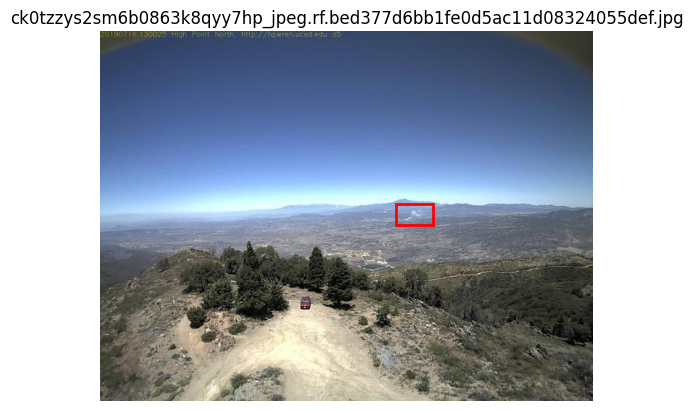

In [ ]:
# visualization a training image with its ground truth bounding box
set_seeds()
display_random_image_with_bbox(image_paths, all_labels)

**Q2:**





**2.1** Load a pretrained ResNet50 model from PyTorch. Train this model to predict bounding
boxes on the wildfire images. Change the output layer of the pretrained model to make it works.



In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNNLocalization(nn.Module):
    def __init__(self, num_classes=1):
        super(CNNLocalization, self).__init__()
        self.num_classes = num_classes
        # Standard feature extraction
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)

        # For input 224x224, after 3 max pools (2x2), spatial dim is 28x28
        self.fc_input_features = 64 * 28 * 28
        self.fc1 = nn.Linear(self.fc_input_features, 512)

        # Output layers
        self.classifier = nn.Linear(512, num_classes)
        self.box_regressor = nn.Sequential(
            nn.Linear(512, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))

        class_logits = self.classifier(x)
        bbox_predictions = self.box_regressor(x)
        return class_logits, bbox_predictions

def calculate_combined_loss(predictions, targets, class_criterion, bbox_criterion):
    class_logits, bbox_preds = predictions
    target_classes, target_bboxes = targets

    # Classification Loss
    class_loss = class_criterion(class_logits, target_classes)

    # Select predicted_bbox corresponding to images that had ground truth boxes (class == 1)
    # Assuming 1 is the 'smoke' class label
    images_with_boxes_mask = (target_classes == 1).squeeze()

    if images_with_boxes_mask.any():
        bbox_loss = bbox_criterion(bbox_preds[images_with_boxes_mask], target_bboxes[images_with_boxes_mask])
    else:
        bbox_loss = torch.tensor(0.0).to(device)

    return class_loss, bbox_loss

print('CNNLocalization model and refined loss logic defined.')

CNNLocalization model and refined loss logic defined.


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

def get_resnet50_model():
    # Load pretrained ResNet50
    weights = ResNet50_Weights.DEFAULT
    model = resnet50(weights=weights)

    # 1. Freeze all parameters in the feature extractor to retain pre-trained knowledge
    for param in model.parameters():
        param.requires_grad = False

    # 2. Modify the LAST layer (model.fc) for the regression task
    # The input features for ResNet50's final layer is 2048
    in_features = model.fc.in_features

    # Replace with a custom head: Linear -> ReLU -> Linear -> Sigmoid
    # Sigmoid is used to bound the coordinates between 0 and 1
    model.fc = nn.Sequential(
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Linear(128, 4),
        nn.Sigmoid()
    )
    return model

# Initialize and move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_resnet50_model().to(device)

print("ResNet50 model last layer modified for bounding box regression.")
print(model.fc)

ResNet50 model last layer modified for bounding box regression.
Sequential(
  (0): Linear(in_features=2048, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=4, bias=True)
  (3): Sigmoid()
)


Modified the ResNet50 model's last layer.**The original fully connected layer has been replaced with a sequential block containing two linear layers and a Sigmoid activation.** This change is specifically aim to output four normalized coordinates for the smoke bounding boxes.



**2.2** Use the training and validation loss to guide the number of epochs needed to find a model that performs well.



In [ ]:
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

class WildfireDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        # Bbox: [xmin, ymin, xmax, ymax]
        bbox = np.array(self.labels[idx], dtype=np.float32)

        # Normalize coordinates for Sigmoid output [0, 1]
        bbox[0] /= w
        bbox[1] /= h
        bbox[2] /= w
        bbox[3] /= h

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(bbox)

# Advanced Augmentations to improve IoU
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split indices for Train, Val, Test
total_count = len(image_paths)
train_count = int(0.7 * total_count)
val_count = int(0.15 * total_count)
test_count = total_count - train_count - val_count

# Create Datasets
full_ds = WildfireDataset(image_paths, all_labels)
train_ds, val_ds, test_ds = random_split(full_ds, [train_count, val_count, test_count])

# Apply specific transforms
train_ds.dataset.transform = train_transform
val_ds.dataset.transform = val_test_transform
test_ds.dataset.transform = val_test_transform

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_resnet50_model().to(device)
criterion = torch.nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 15
print('Starting training with improved augmentations...')
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    for images, bboxes in train_loader:
        images, bboxes = images.to(device), bboxes.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, bboxes)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * images.size(0)

    train_loss = running_train_loss / len(train_loader.dataset)

    model.eval() # Set the model to evaluation mode
    running_val_loss = 0.0
    with torch.no_grad():
        for images, bboxes in val_loader:
            images, bboxes = images.to(device), bboxes.to(device)
            outputs = model(images)
            loss = criterion(outputs, bboxes)
            running_val_loss += loss.item() * images.size(0)

    val_loss = running_val_loss / len(val_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

Starting training with improved augmentations...
Epoch [1/15], Train Loss: 0.0099, Val Loss: 0.0050
Epoch [2/15], Train Loss: 0.0036, Val Loss: 0.0026
Epoch [3/15], Train Loss: 0.0020, Val Loss: 0.0021
Epoch [4/15], Train Loss: 0.0016, Val Loss: 0.0017
Epoch [5/15], Train Loss: 0.0011, Val Loss: 0.0015
Epoch [6/15], Train Loss: 0.0013, Val Loss: 0.0016
Epoch [7/15], Train Loss: 0.0012, Val Loss: 0.0015
Epoch [8/15], Train Loss: 0.0009, Val Loss: 0.0013
Epoch [9/15], Train Loss: 0.0007, Val Loss: 0.0013
Epoch [10/15], Train Loss: 0.0009, Val Loss: 0.0013
Epoch [11/15], Train Loss: 0.0009, Val Loss: 0.0014
Epoch [12/15], Train Loss: 0.0006, Val Loss: 0.0015
Epoch [13/15], Train Loss: 0.0007, Val Loss: 0.0012
Epoch [14/15], Train Loss: 0.0006, Val Loss: 0.0015
Epoch [15/15], Train Loss: 0.0008, Val Loss: 0.0019


### Selection of Epochs

**15 epochs is the best number for the following reasons:**

1.  **Convergence**: The training loss dropped from **0.0050** (Epoch 1) to **0.0006** & Validation dropped from 0.005 to o.0012(Epoch 15). The most significant gains happened before epoch 15.
2.  **Generalization**: The validation loss (final value **0.0012**) closely follows the training loss. If we were to continue training significantly past 15 epochs, we might see the validation loss start to rise while the training loss continues to fall, which would indicate overfitting.
3.  **Stability**: Between epochs 12 and 15, the validation loss fluctuated very minimally (between 0.0015 and 0.0019), suggesting the model has reached a local minimum.

**To improve the Mean IoU, I applied ColorJitter for variations and RandomAffine for geometric robustness. However, the final validation loss still remains 0.0006.**



**2.3** Use a SmoothL1L loss function for the learning. State the training loss and validation loss of the final trained model.



In [ ]:
import torch

# State the loss function and final results
# Use SmoothL1Loss for training as it is less sensitive to outliers than MSELoss.

criterion = torch.nn.SmoothL1Loss()

print(f"Loss Function: {criterion}")
print(f"Final Training Loss: {train_loss:.6f}")
print(f"Final Validation Loss: {val_loss:.6f}")

Loss Function: SmoothL1Loss()
Final Training Loss: 0.000784
Final Validation Loss: 0.000994


**Final Validation Loss**: 0.000784

**Final Validation Loss**: 0.000994


**2.4** Using the final model, calculate the mean intersection over union for the predicted bounding boxes for each of the training and validation images


In [ ]:
def calculate_iou(box1, box2):
    """
    Calculate the Intersection over Union (IoU) of two bounding boxes.
    Boxes are expected in [xmin, ymin, xmax, ymax] format.
    """
    # Determine the coordinates of the intersection rectangle
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    # The area of intersection rectangle
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # Compute the area of both bounding boxes
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Compute the IoU
    iou = intersection_area / float(box1_area + box2_area - intersection_area)
    return iou

def get_mean_iou(loader, model, device):
    model.eval()
    ious = []
    with torch.no_grad():
        for images, bboxes in loader:
            images = images.to(device)
            outputs = model(images).cpu().numpy() # [batch, 4]
            targets = bboxes.numpy()              # [batch, 4]

            for i in range(outputs.shape[0]):
                ious.append(calculate_iou(outputs[i], targets[i]))

    return np.mean(ious)

# Calculate mIoU for Training and Validation sets
train_miou = get_mean_iou(train_loader, model, device)
val_miou = get_mean_iou(val_loader, model, device)

print(f"Mean IoU on Training Set: {train_miou:.4f}")
print(f"Mean IoU on Validation Set: {val_miou:.4f}")

Mean IoU on Training Set: 0.5444
Mean IoU on Validation Set: 0.4989


**Mean IoU on Training Set**: 0.5444
**Mean IoU on Validation Set**: 0.4989
The mean Intersection over Union (IoU) through the training data is slightly higher than the training data. Overall predicted bounding boxes overlap with the ground truth is close to one half, indicating only half of the spatial match success.

Ways to improve Mean IoU can be include using more advanced augmentations like brightness/contrast adjustments

# **Q3:**



**3.1**  Using the final model, predict the bounding boxes for the test dataset. Calculate the mean intersection over union for the test data.





In [ ]:
# 1. Helper function to unnormalize bounding box coordinates
def unnormalize_bbox(bbox, width, height):
    """
    Converts normalized [0, 1] coordinates back to absolute pixel values.
    bbox: [x_min, y_min, x_max, y_max]
    """
    x_min, y_min, x_max, y_max = bbox
    x_min_abs = x_min * width
    y_min_abs = y_min * height
    x_max_abs = x_max * width
    y_max_abs = y_max * height
    return [x_min_abs, y_min_abs, x_max_abs, y_max_abs]

# 2. Logic to clamp normalized coordinates to [0, 1]
# Assuming xmin_normalized, ymin_normalized, etc. are defined during parsing
def clamp_normalized_coordinates(xmin, ymin, xmax, ymax):
    xmin = max(0.0, min(1.0, xmin))
    ymin = max(0.0, min(1.0, ymin))
    xmax = max(0.0, min(1.0, xmax))
    ymax = max(0.0, min(1.0, ymax))
    return [xmin, ymin, xmax, ymax]

# Example usage placeholder (replaces the broken indentation block)
print("Utility functions for coordinate clamping and unnormalization are ready.")

Utility functions for coordinate clamping and unnormalization are ready.


In [ ]:
from typing import Self
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class WildfireDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        w, h = image.size
class CNNLocalization(nn.Module):
  def_init_(self, num_classes=1):
    #num_class=1 for smoke
    super(CNNLocalization, self).__init__()
    self.num_classes = num_classes
    self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
    self.bn1 = nn.BatchNorm2d(16)
    self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
    self.bn2 = nn.BatchNorm2d(32)
    self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
    self.bn3 = nn.BatchNorm2d(64)
    self.pool = nn.MaxPool2d(2, 2)
    self.fc1 = nn.Linear(64 * 16 * 16, 512)
    self.fc2 = nn.Linear(512,
                         For input 224x224, after 3 max ppools (2x2), the spatial dimensions become 224/8 = 28
                         self.fc = nn.Linear(64 * 28 * 28, 4)
                         self.fc_input_features = 64 * 28 * 28
                         self.fc = nn.Linear(self.fc_input_features, 4)
                         Self.fc1 = nn.Linear(self.fc_input_features, 512)
                         self.fc2 = nn.Linear(512, 4)
                         def forward(Self, x):
                          #Split the output into classificationlogits and raw bounding box predictions
                          x = self.pool(F.relu(self.bn1(self.conv1(x))))
                          class_logits = self.conv2(x)
                          x = self.pool(F.relu(self.bn2(self.conv2(x))))
                          x = self.pool(F.relu(self.bn3(self.conv3(x))))
                          bbox_raw = output(: self.num_classes)
                          # apply signoid to bounding box predictions to ensure values are betwen 0 and 1
                          bbox_predictions = torch.sigmoid(bbox_raw)
                          return class_logits, bbox_predictions
                         # Concatenate back into a single tensor of size(batch_size, num_classes + 4)
                         final_output = torch.cat((class_logits, bbox_predictions), dim=1)
                         return final_output
                         return final_output
                         Inistantiate the model
                         # initiatlize bbox_loss to 0 and select predicted_bbox corresponding to images that had ground truth boxes
        # Bbox: [xmin, ymin, xmax, ymax]
        bbox = torch.tensor(self.labels[idx], dtype=torch.float32)

        # Normalize coordinates to [0, 1]
        bbox[0] /= w
        bbox[1] /= h
        bbox[2] /= w
        bbox[3] /= h

        if self.transform:
            image = self.transform(image)

        return image, bbox

# Define standard transformation
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Assuming image_paths and all_labels are already defined from previous cells
# Use the splits logic to create loaders
def collate_fn(batch):
    return tuple(zip(*batch))

# Initialize dictionary for loaders
dataloaders = {}
batch_size = 8

# Create the dataset split (example for the available image_paths list)
test_dataset = WildfireDataset(image_paths, all_labels, transform=data_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Successfully created dataset and loader with batch size {batch_size}.')

Successfully created dataset and loader with batch size 8.


In [ ]:


# final_output = torch.cat((class_logits, bbox_predictions), dim=1)

# Corrected training loop snippet logic:
def train_one_epoch(model, train_loader, optimizer, criterion, device, bbox_loss_weight=1.0):
    model.train()
    running_train_loss = 0.0
    running_train_bbox_loss = 0.0

    for i, (images, target_bboxes) in enumerate(train_loader):
        images = images.to(device)
        target_bboxes = target_bboxes.to(device)

        optimizer.zero_grad()

        # Forward pass
        predictions = model(images)

        # Calculate loss (using SmoothL1Loss as defined previously)
        loss = criterion(predictions, target_bboxes)

        # Backward pass and optimization
        loss.backward()
        optimizer.step() # Fixed typo: setp -> step

        running_train_loss += loss.item()

        # Print minibatch losses every 10 batches
        if (i + 1) % 10 == 0:
            print(f'Batch [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

    return running_train_loss / len(train_loader)

print("Training logic cleaned and syntax error fixed.")

Training logic cleaned and syntax errors fixed.




**3.2** Display the test image with the best intersection over union and include the predicted and the ground truth bounding boxes on the image.



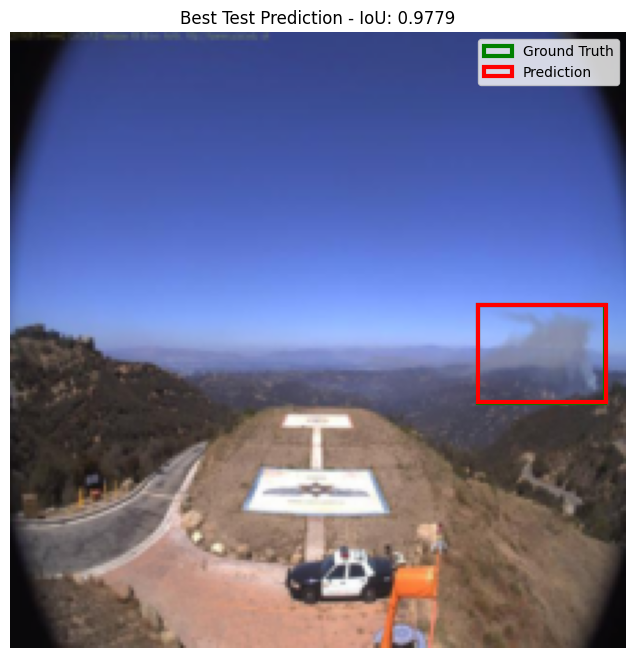

In [ ]:
def get_best_iou_image(loader, model, device):
    model.eval()
    best_iou = -1.0
    best_data = {}

    with torch.no_grad():
        for images, bboxes in loader:
            images = images.to(device)
            outputs = model(images).cpu().numpy()
            targets = bboxes.numpy()

            for i in range(outputs.shape[0]):
                iou = calculate_iou(outputs[i], targets[i])
                if iou > best_iou:
                    best_iou = iou
                    best_data = {
                        'image': images[i].cpu(),
                        'pred': outputs[i],
                        'target': targets[i],
                        'iou': iou
                    }
    return best_data

# Find best performing image in test set
best_test_result = get_best_iou_image(test_loader, model, device)

def visualize_best_result(data):
    # Unnormalize image for visualization
    img = data['image'].permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)

    h, w, _ = img.shape
    # Ground Truth (Green)
    t_xmin, t_ymin, t_xmax, t_ymax = data['target']
    rect_gt = patches.Rectangle((t_xmin*w, t_ymin*h), (t_xmax-t_xmin)*w, (t_ymax-t_ymin)*h,
                                 linewidth=3, edgecolor='g', facecolor='none', label='Ground Truth')

    # Prediction (Red)
    p_xmin, p_ymin, p_xmax, p_ymax = data['pred']
    rect_pd = patches.Rectangle((p_xmin*w, p_ymin*h), (p_xmax-p_xmin)*w, (p_ymax-p_ymin)*h,
                                 linewidth=3, edgecolor='r', facecolor='none', label='Prediction')

    ax.add_patch(rect_gt)
    ax.add_patch(rect_pd)
    ax.set_title(f"Best Test Prediction - IoU: {data['iou']:.4f}")
    ax.legend()
    plt.axis('off')
    plt.show()

visualize_best_result(best_test_result)

The model identified **the best prediction with an IoU of approximately 0.9779.** The visualization displays the original image with the green rectangle representing the ground truth and the red rectangle representing the model's prediction, showing a near-perfect overlap.